In [54]:
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

from strhub.data.module import SceneTextDataModule
from strhub.models.utils import load_from_checkpoint

ckpt = "/home/abhinavchadaga/cs/fri_II/final_project/parseq/outputs/parseq/2022-12-04_16-17-25/checkpoints/last.ckpt"

# Load model and image transforms
parseq = load_from_checkpoint(checkpoint_path=ckpt)
img_transform = SceneTextDataModule.get_transform(parseq.hparams.img_size)

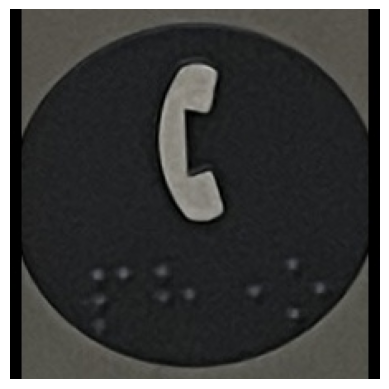

In [55]:
img_path = "/home/abhinavchadaga/cs/fri_II/final_project/data/labels/val/ahg_10_call.jpg"
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess. Model expects a batch of images with shape: (B, C, H, W)
img = img_transform(img).unsqueeze(0)

In [56]:
logits = parseq(img)
logits.shape  # torch.Size([1, 26, 95]), 94 characters + [EOS] symbol

torch.Size([1, 26, 95])

In [57]:
# Greedy decoding
pred = logits.softmax(-1)
label, confidence = parseq.tokenizer.decode(pred)
print('Decoded label = {}'.format(label[0]))

Decoded label = call
